In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
from scipy.stats import norm # for the Gaussian PDF function
from scipy.stats import binom

In [2]:
seed = 42
x_dist = pm.Normal.dist(shape=(100, 3))
x_data = pm.draw(x_dist, random_seed=seed)

coords={
 "trial": range(100),
 "features": ["sunlight hours", "water amount", "soil nitrogen"],
}

# Define generative model
with pm.Model(coords=coords) as generative_model:
   x = pm.Data("x", x_data, dims=["trial", "features"])

   # Model parameters
   betas = pm.Normal("betas", dims="features")
   sigma = pm.HalfNormal("sigma")

   # Linear model
   mu = x @ betas

   # Likelihood
   # Assuming we measure deviation of each plant from baseline
   plant_growth = pm.Normal("plant growth", mu, sigma, dims="trial")


# Generating data from model by fixing parameters
fixed_parameters = {
 "betas": [5, 20, 2],
 "sigma": 0.5,
}
with pm.do(generative_model, fixed_parameters) as synthetic_model:
   idata = pm.sample_prior_predictive(random_seed=seed) # Sample from prior predictive distribution.
   synthetic_y = idata.prior["plant growth"].sel(draw=0, chain=0)


# Infer parameters conditioned on observed data
with pm.observe(generative_model, {"plant growth": synthetic_y}) as inference_model:
   idata = pm.sample(random_seed=seed)

   summary = pm.stats.summary(idata, var_names=["betas", "sigma"])
   print(summary)

Sampling: [plant growth]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 130 seconds.


                         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
betas[sunlight hours]   4.973  0.053   4.872    5.071      0.001    0.001   
betas[water amount]    19.964  0.049  19.871   20.055      0.001    0.001   
betas[soil nitrogen]    1.996  0.056   1.895    2.100      0.001    0.001   
sigma                   0.511  0.037   0.445    0.582      0.000    0.001   

                       ess_bulk  ess_tail  r_hat  
betas[sunlight hours]    5469.0    3527.0    1.0  
betas[water amount]      5776.0    3157.0    1.0  
betas[soil nitrogen]     4913.0    3428.0    1.0  
sigma                    5603.0    3476.0    1.0  


##### Plot Gaussian probability density function for a couple of different standard deviations in range from 0.2 to 2 (all in one plot). Label the axes appropriately.

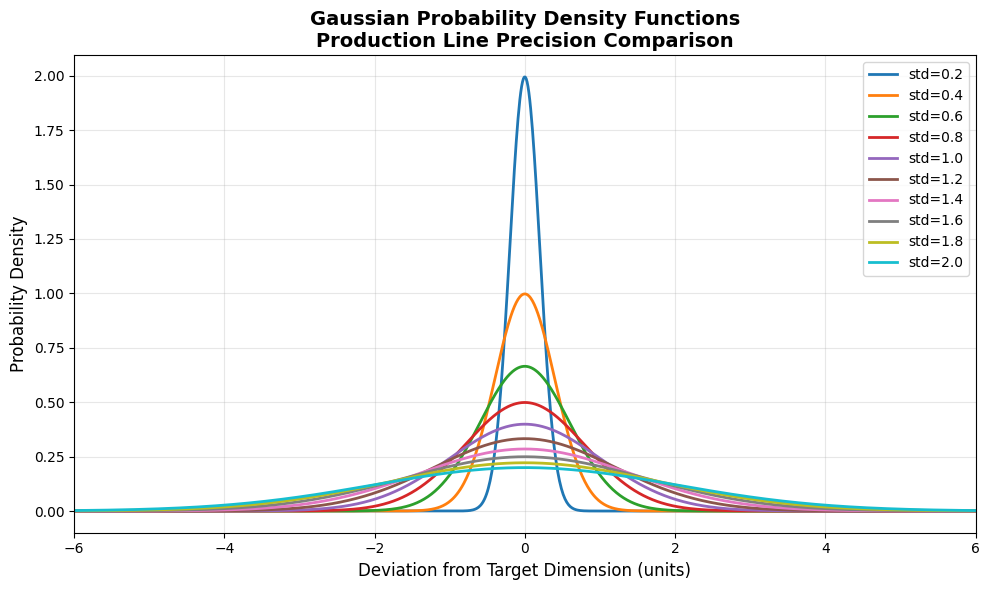

In [14]:
x = np.linspace(-6, 6, 1000)

std_devs = np.arange(0.2, 2.1, 0.2)

plt.figure(figsize=(10, 6))

for std in std_devs:
    pdf = norm.pdf(x, loc=0, scale=std) # loc is mean, scale is std
    plt.plot(x, pdf, linewidth=2, label=f'std={std:.1f}')

plt.xlabel('Deviation from Target Dimension (units)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Gaussian Probability Density Functions\nProduction Line Precision Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(-6, 6)

plt.tight_layout()
plt.show()

##### Plot Gaussian cumulative density function for a couple of different standard deviations in range from 0.2 to 2 (all in one plot). Label the axes appropriately.

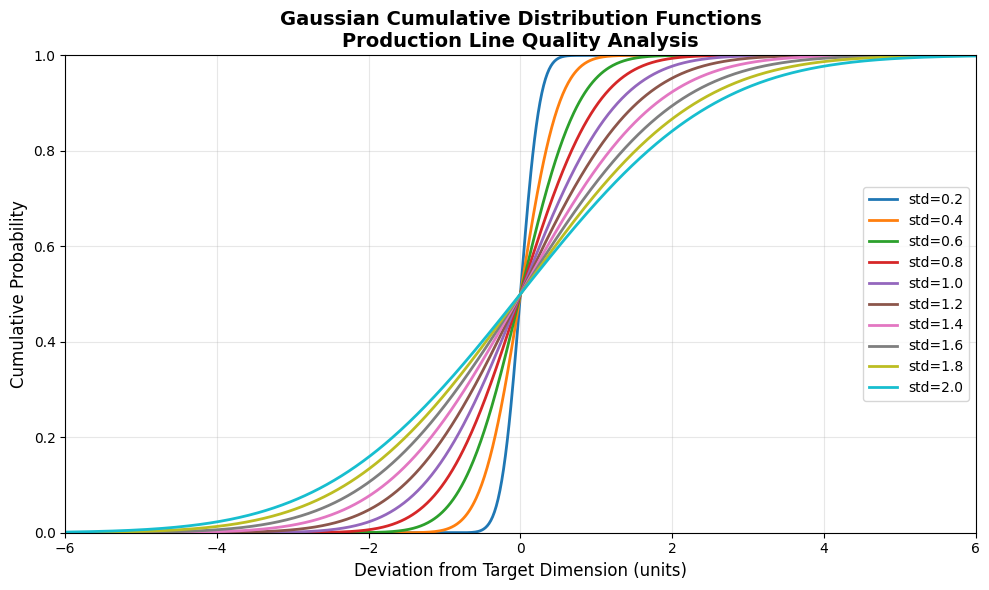

In [15]:
# Steeper curves = higher precision (faster approach to 0 and 1)

x = np.linspace(-6, 6, 1000)

std_devs = np.arange(0.2, 2.1, 0.2)

plt.figure(figsize=(10, 6))

for std in std_devs:
    cdf = norm.cdf(x, loc=0, scale=std) # loc is mean, scale is std
    plt.plot(x, cdf, linewidth=2, label=f'std={std:.1f}')

plt.xlabel('Deviation from Target Dimension (units)', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)
plt.title('Gaussian Cumulative Distribution Functions\nProduction Line Quality Analysis', fontsize=14, fontweight='bold')
plt.legend(loc='center right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(-6, 6)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

##### Combined plot with PDF and CDF subplots

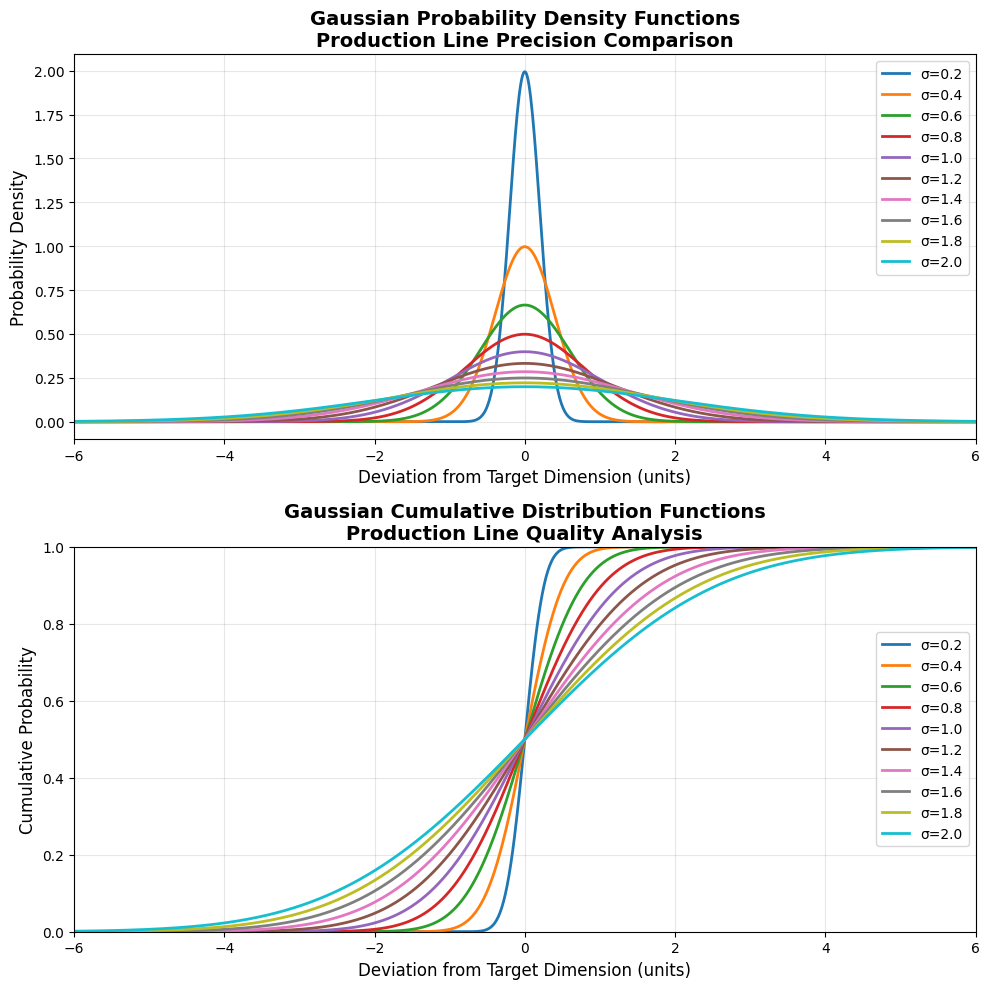

In [18]:
x = np.linspace(-6, 6, 1000)
std_devs = np.arange(0.2, 2.1, 0.2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

for std in std_devs:
    pdf = norm.pdf(x, loc=0, scale=std)
    ax1.plot(x, pdf, linewidth=2, label=f'σ={std:.1f}')

ax1.set_xlabel('Deviation from Target Dimension (units)', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title('Gaussian Probability Density Functions\nProduction Line Precision Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-6, 6)

for std in std_devs:
    cdf = norm.cdf(x, loc=0, scale=std)
    ax2.plot(x, cdf, linewidth=2, label=f'σ={std:.1f}')

ax2.set_xlabel('Deviation from Target Dimension (units)', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.set_title('Gaussian Cumulative Distribution Functions\nProduction Line Quality Analysis', fontsize=14, fontweight='bold')
ax2.legend(loc='center right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-6, 6)
ax2.set_ylim(0, 1)


plt.tight_layout()
plt.show()

#### Plot binomial probability mass function for Bi(10, 0.5) and Bi(10, 0.1). Plot both in one plot (not subplots). Use red dots for the first one, green crosses for the second one. Add legend to the plot.

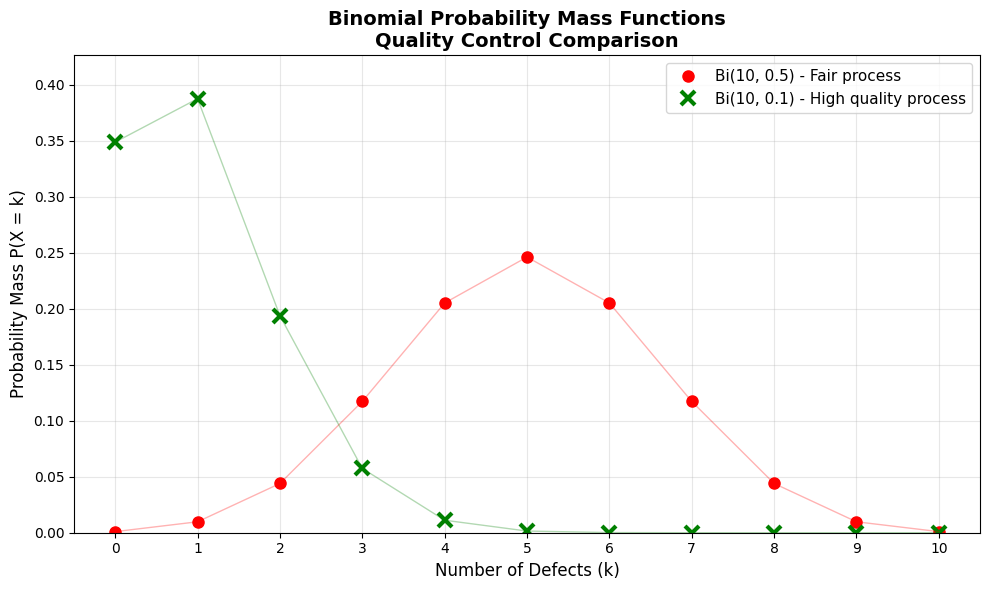

In [ ]:
n = 10  # number of trials
p1 = 0.5  # probability for first distribution (fair)
p2 = 0.1  # probability for second distribution (high quality)

# Possible values (0 to 10 defects)
k = np.arange(0, n + 1)

pmf1 = binom.pmf(k, n, p1)  # Bi(10, 0.5)
pmf2 = binom.pmf(k, n, p2)  # Bi(10, 0.1)

plt.figure(figsize=(10, 6))

plt.plot(k, pmf1, 'ro', markersize=8, linewidth=2, label='Bi(10, 0.5) - Fair process')
plt.plot(k, pmf2, 'gx', markersize=10, markeredgewidth=3, label='Bi(10, 0.1) - High quality process')

plt.plot(k, pmf1, 'r-', alpha=0.3, linewidth=1)
plt.plot(k, pmf2, 'g-', alpha=0.3, linewidth=1)

# Formatting
plt.xlabel('Number of Defects (k)', fontsize=12)
plt.ylabel('Probability Mass P(X = k)', fontsize=12)
plt.title('Binomial Probability Mass Functions\nQuality Control Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 10.5)
plt.ylim(0, max(max(pmf1), max(pmf2)) * 1.1)

plt.xticks(k)

plt.tight_layout()
plt.show()